题目描述：
已知一个三层前馈神经网络（全连接），结构如下：
输入层：2 个神经元
隐藏层1：3 个神经元，激活函数为 ReLU
隐藏层2：2 个神经元，激活函数为 Sigmoid
输出层：2 个神经元（对应二分类），无激活（CrossEntropyLoss 自动加 softmax）
参数初始化（均需 requires_grad=True）：
W1 = [[0.2, -0.1], [0.1, 0.3], [-0.2, 0.2]] # shape = [3, 2]
b1 = [0.0, 0.1, -0.1] # shape = [3]
W2 = [[0.1, -0.2, 0.2], [-0.1, 0.1, 0.1]] # shape = [2, 3]
b2 = [0.0, 0.05] # shape = [2]
W3 = [[0.3, -0.2], [0.2, 0.1]] # shape = [2, 2]
b3 = [0.1, -0.1] # shape = [2]
输入特征与标签：
X = [[1.5, -2.0]] # shape = [1, 2]
y = 1 # 类别1
计算要求：
前向传播
计算隐藏层1输出 H1 = ReLU(X @ W1^T + b1)
计算隐藏层2输出 H2 = Sigmoid(H1 @ W2^T + b2)
计算输出层 Z = H2 @ W3^T + b3
用 nn.CrossEntropyLoss() 计算损失
反向传播
loss.backward()，获得各参数的梯度
参数更新
用学习率 lr=0.1，手动SGD更新一次参数（不使用优化器）
输出结果
打印 softmax 后的输出概率
打印损失值
打印每个参数的梯度
打印更新后的参数值

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [5]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [6]:
def forward(w1, w2, w3, b1, b2, b3, x):
  z1 = x @ w1.T + b1
  h1 = torch.relu(z1)

  z2 = h1 @ w2.T + b2
  h2 = torch.sigmoid(z2)

  z3 = h2 @ w3.T + b3
  return z3

epoch: 1 loss: 0.7451
epoch: 11 loss: 0.2955
epoch: 21 loss: 0.1673
epoch: 31 loss: 0.1133
epoch: 41 loss: 0.0845
epoch: 51 loss: 0.0669
epoch: 61 loss: 0.0551
epoch: 71 loss: 0.0467
epoch: 81 loss: 0.0404
epoch: 91 loss: 0.0355
epoch: 101 loss: 0.0317
epoch: 111 loss: 0.0285
epoch: 121 loss: 0.0259
epoch: 131 loss: 0.0238
epoch: 141 loss: 0.0219
epoch: 151 loss: 0.0203
epoch: 161 loss: 0.0189
epoch: 171 loss: 0.0177
epoch: 181 loss: 0.0166
epoch: 191 loss: 0.0156
the y_pred index value is:
tensor(1)
the y_true index value is:
tensor([1])


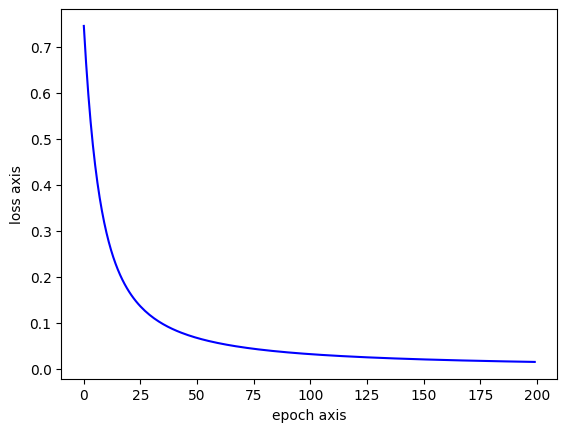

In [12]:
#初始化
w1 = torch.tensor([[0.2, -0.1], [0.1, 0.3], [-0.2, 0.2]], requires_grad=True) # shape = [3, 2]
b1 = torch.tensor([0.0, 0.1, -0.1], requires_grad=True) # shape = [3]
w2 = torch.tensor([[0.1, -0.2, 0.2], [-0.1, 0.1, 0.1]], requires_grad=True) # shape = [2, 3]
b2 = torch.tensor([0.0, 0.05], requires_grad=True) # shape = [2]
w3 = torch.tensor([[0.3, -0.2], [0.2, 0.1]], requires_grad=True) # shape = [2, 2]
b3 = torch.tensor([0.1, -0.1], requires_grad=True) # shape = [2]

x = torch.tensor([[1.5, -2.0]])
y_true_index = torch.tensor([1])

losses = []
epochs = 200

lr = 0.1

criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
  z3 = forward(w1, w2, w3, b1, b2, b3, x)
  y_pred = torch.softmax(z3, dim=1)

  loss = criterion(z3, y_true_index)
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    w3 -= lr * w3.grad
    b1 -= lr * b1.grad
    b2 -= lr * b2.grad
    b3 -= lr * b3.grad

  w1.grad.zero_()
  w2.grad.zero_()
  w3.grad.zero_()
  b1.grad.zero_()
  b2.grad.zero_()
  b3.grad.zero_()

  if epoch % 10 == 0:
    print(f"epoch: {epoch + 1}",
       f"loss: {loss.item():.4f}")

with torch.no_grad():
  y_pred_index = torch.argmax(y_pred)

print("the y_pred index value is:")
print(y_pred_index)

print("the y_true index value is:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.show()